## Import Libraries

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import bernoulli, binom, poisson, lognorm, powerlaw, norm, zscore

from scipy.stats import boxcox
import statsmodels.api as sm

## Import Data

In [59]:
df = pd.read_excel("spread_locator_dataset.xlsx")

df


,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success
...,...,...,...,...,...,...,...
215,10c2a8f2-89d0-485c-bf8f-9508d32a02fc,CUST5563,4356.76,2023-01-12,2,South,Fail
216,5618814b-f7e2-424d-9617-9fc8d8643370,CUST8579,2025.53,2023-01-29,6,South,Fail
217,5636c9e7-9d54-4654-9c89-fdf31be87d96,CUST5092,2648.08,2023-01-30,1,West,Fail
218,6ba09450-a455-4983-bbad-3dad292cc839,CUST2235,2338.62,2023-01-26,3,North,Success


## Q1 Fit the data to Bernoulli and Binomial distrubutions

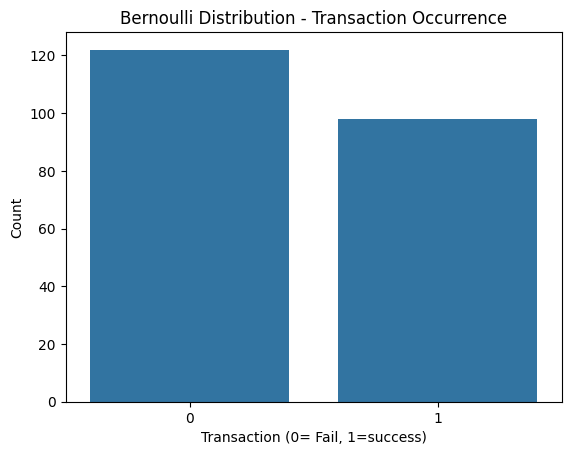

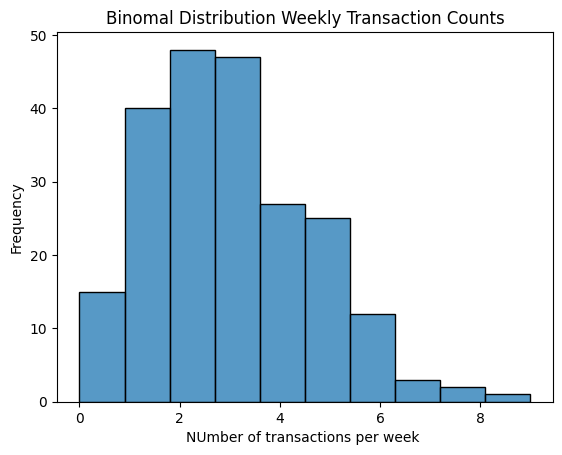

In [60]:
# Bernoulli

#Success = 1, fail = 0

df["transaction_occurrence"] = df["transaction_status"].map({
    "Success" : 1,
    "Fail": 0
})

sns.countplot(x=df["transaction_occurrence"])
plt.title("Bernoulli Distribution - Transaction Occurrence")
plt.xlabel("Transaction (0= Fail, 1=success)")
plt.ylabel("Count")
plt.show()

## Binomial Distribution

sns.histplot(df["transaction_count"], bins=10)

plt.title("Binomal Distribution Weekly Transaction Counts")
plt.xlabel("NUmber of transactions per week ")
plt.ylabel("Frequency")

plt.show()

## Question 1(A): Bernoulli Distribution Interpretation

## Interpretation:

The Bernoulli distribution represents whether a transaction is successful (1) or failed (0).

From the graph, the number of failed transactions (0) is higher than the number of successful transactions (1).

This indicates that the probability of failure is greater than the probability of success in the dataset.

Since each transaction has only two possible outcomes (Success or Failure), the Bernoulli distribution is an appropriate model for this data.

## Question 1(B): Binomial Distribution Interpretation

## Interpretation:

The histogram shows the weekly number of transactions.

Most weeks have 2 to 4 transactions, which is where the highest frequency is observed.

Weeks with 6 or more transactions are less common.

The distribution is concentrated around the middle values, indicating that the weekly transaction count is fairly consistent.

Therefore, the Binomial distribution is suitable for modeling the weekly transaction counts.

## Question 2: Poisson Distribution

Lambda: 7.096774193548387


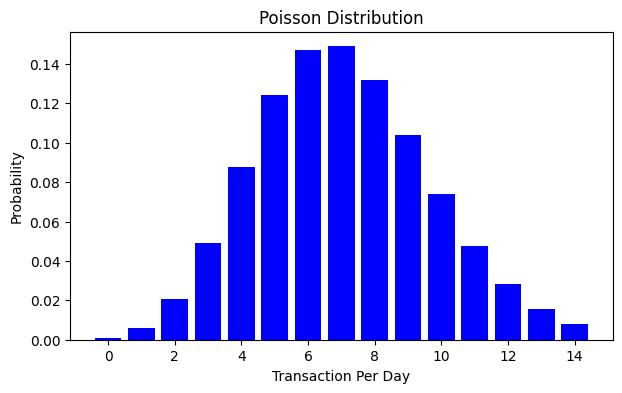

In [61]:
daily_transaction = df.groupby("transaction_date").size()

lam = daily_transaction.mean()
print("Lambda:",lam)

x = np.arange(0,daily_transaction.max()+3)

pmf = poisson.pmf(x,lam)

plt.figure(figsize=(7,4))
plt.bar(x,pmf,color='blue')
plt.title("Poisson Distribution")
plt.xlabel("Transaction Per Day")
plt.ylabel("Probability")
plt.show()

## Interpretation

The graph represents the Poisson distribution for the number of transactions per day.

The highest probability is around 6–7 transactions per day, indicating that this is the most common daily transaction count.

The probability decreases as the number of transactions moves away from 6–7, meaning very low or very high transaction counts occur less frequently.

The distribution is right-skewed, which is a common characteristic of Poisson-distributed count data.

Therefore, the Poisson distribution is suitable for modeling the number of transactions occurring per day.

## Question 3: Model Transaction Amounts using Log-Normal and Power Law Distributions

## Log - Normal Distribution

Shap: 0.4749178350151927
Scale: 2983.1591334067753


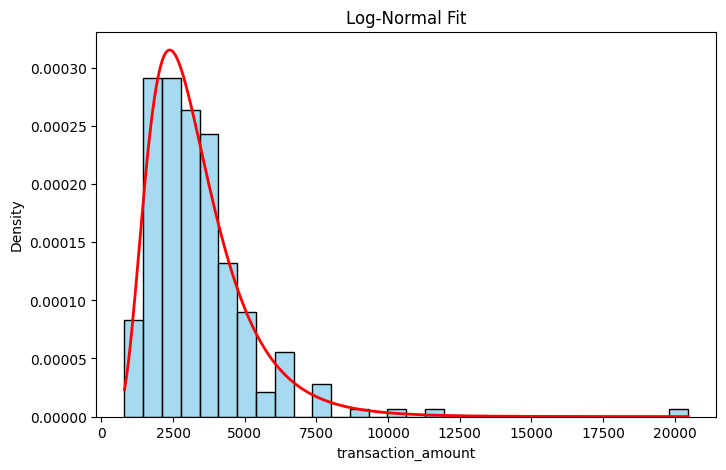

In [62]:
amt = df['transaction_amount']

shape , loc, scale = lognorm.fit(amt,floc=0)

print("Shap:", shape)
print("Scale:",scale)

plt.figure(figsize=(8,5))

sns.histplot(amt, bins = 30, stat='density', color='skyblue')

x=np.linspace(amt.min(),amt.max(), 300)

pdf= lognorm.pdf(x, shape, loc, scale)

plt.plot(x, pdf, 'r', linewidth=2)
plt.title("Log-Normal Fit")
plt.show()

## Question 3: Log-Normal Distribution Interpretation

## Interpretation:

The histogram shows the distribution of transaction amounts.

The red curve represents the fitted Log-Normal Distribution.

Most transaction amounts are concentrated between ₹1,500 and ₹4,000.

As the transaction amount increases, the number of transactions decreases.

A few transactions have very high amounts (around ₹10,000–₹20,000), creating a long right tail.

The Log-Normal curve closely follows the shape of the histogram, indicating that it provides a good fit for the transaction amount data.

This shows that the transaction amounts are positively (right) skewed rather than normally distributed.

## Power-Law Distribution

shape: 0.41232325172331613


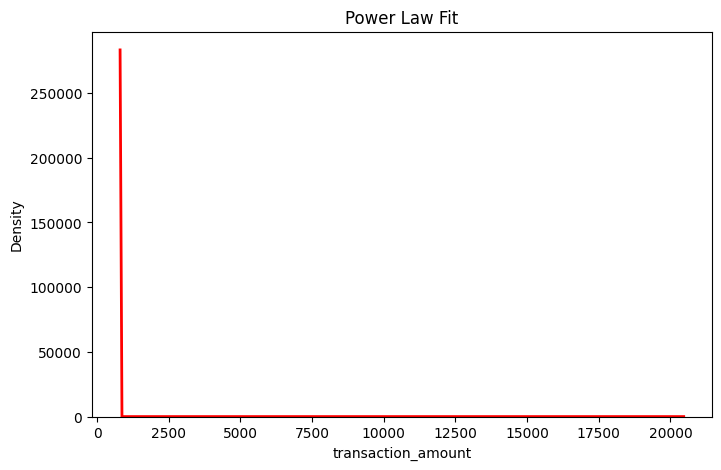

In [63]:
shape, loc, scale= powerlaw.fit(amt)
print("shape:",shape)

pdf= powerlaw.pdf(x, shape, loc, scale)
plt.figure(figsize=(8,5))

sns.histplot(amt, bins=30, stat="density", color='green')

plt.plot(x, pdf, 'red', linewidth = 2 )

plt.title("Power Law Fit")
plt.show()

## Interpretation

The graph shows the Power Law Distribution fitted to the transaction amount data.

The fitted curve has a very high peak at lower transaction amounts and quickly drops to nearly zero.

The curve does not follow the histogram of the transaction amounts, indicating a poor fit.

This suggests that the transaction amount data does not follow a Power Law Distribution.

Compared with the Log-Normal Distribution, the Power Law Distribution provides a weaker fit for this dataset.

## Question 4: Generate and Interpret a Q-Q Plot to Test Normality

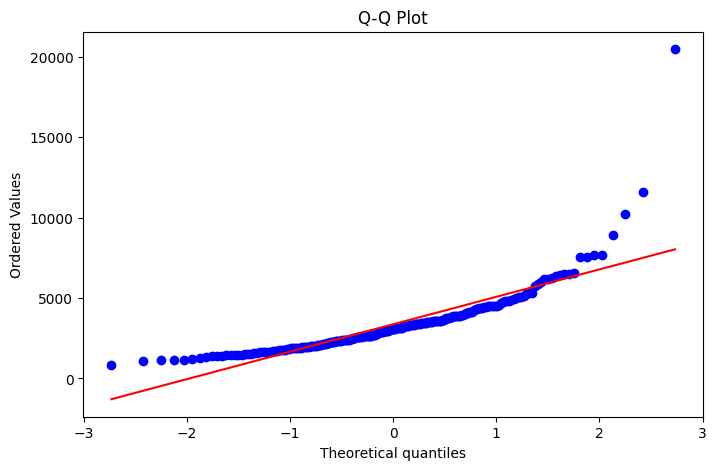

Shapiro-Wilk Test Statistics: 0.7360905663247675
p-value: 1.9104194773842295e-18
Data is Not Normally Distributed


In [64]:
plt.figure(figsize=(8,5))

stats.probplot(amt, dist="norm", plot=plt)
plt.title("Q-Q Plot")

plt.show()

# Sharpiro-Wilk test

stats, pvalue = stats.shapiro(amt)
print("Shapiro-Wilk Test Statistics:", stats)
print("p-value:", pvalue)

if pvalue > 0.05:
    print("Data appear Normally Distributed")
else:
    print("Data is Not Normally Distributed")

## Interpretation:

The Q-Q Plot compares the transaction amount data with a normal distribution.

The data points do not lie on the red reference line.

The points in the middle are close to the line, but the points at both ends, especially the upper end, deviate significantly from it.

This indicates that the transaction amounts are not normally distributed.

The upper-right points are far above the line, showing the presence of high-value transactions (outliers) and a long right tail.

Therefore, the data is positively (right) skewed.

## Question 5: Apply Box-Cox Transform to Stabilize Variance

Optimal Lambda = -0.18123612911845818


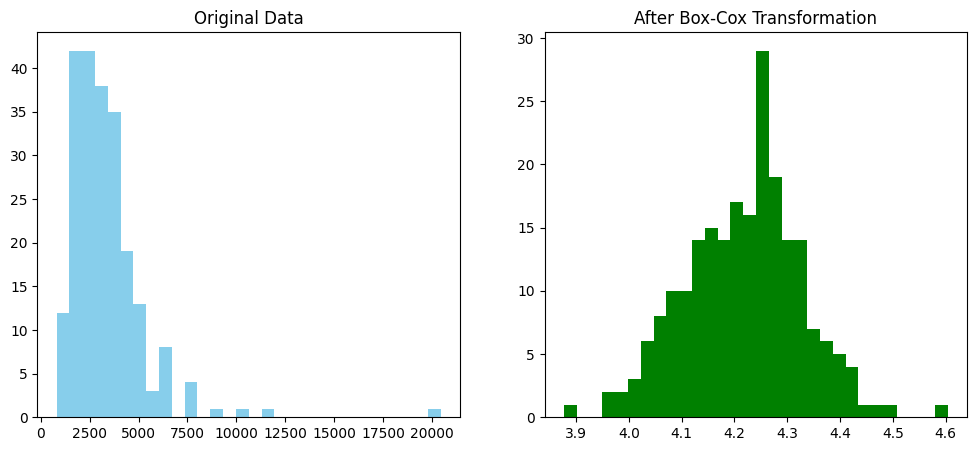

In [65]:

positive = amt + 1

transformed, lamda = boxcox(positive)
print("Optimal Lambda =", lamda)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(amt, bins=30, color='skyblue')
plt.title("Original Data")

plt.subplot(1,2,2)
plt.hist(transformed, bins=30, color='green')
plt.title("After Box-Cox Transformation")

plt.show()

## Interpretation:

The left histogram (Original Data) shows that the transaction amounts are positively (right) skewed. Most transactions are of lower amounts, while a few 

transactions have very high values, creating a long right tail.

The right histogram (After Box-Cox Transformation) shows that the data has become more symmetric and bell-shaped.

The transformation has reduced the skewness and minimized the effect of extreme values (outliers).

As a result, the variance of the data is more stable, making it more suitable for statistical analysis and machine learning models.

## Question 6: Calculate Z-Scores for Transaction Amounts and Compute Probability of Transactions Exceeding ₹5000

In [66]:
# Calculate Z-Score

df["Z_score"] = zscore(amt)

print(df[["transaction_amount","Z_score"]].head())

# Probability of transaction amount > ₹5000

mean = amt.mean()
std = amt.std()

prob = 1-norm.cdf(5000, loc=mean, scale=std)

print("Probability of transaction Amount > ₹5000:", prob)

   transaction_amount   Z_score
0             3821.34  0.230240
1             2781.84 -0.294446
2             4120.97  0.381477
3             6383.78  1.523626
4             2651.61 -0.360179
Probability of transaction Amount > ₹5000: 0.20517209567554384


## Interpretation:

The Z-score measures how far each transaction amount is from the mean in terms of standard deviations.

A positive Z-score indicates that the transaction amount is above the average, while a negative Z-score indicates it is below the average.

The probability of a transaction exceeding ₹5000 is calculated using the cumulative distribution function (CDF) of the normal distribution.

A lower probability indicates that transactions above ₹5000 are relatively uncommon in the dataset.

## Question 7: Plot and Interpret PDF and CDF for Transaction Amounts

## PDF

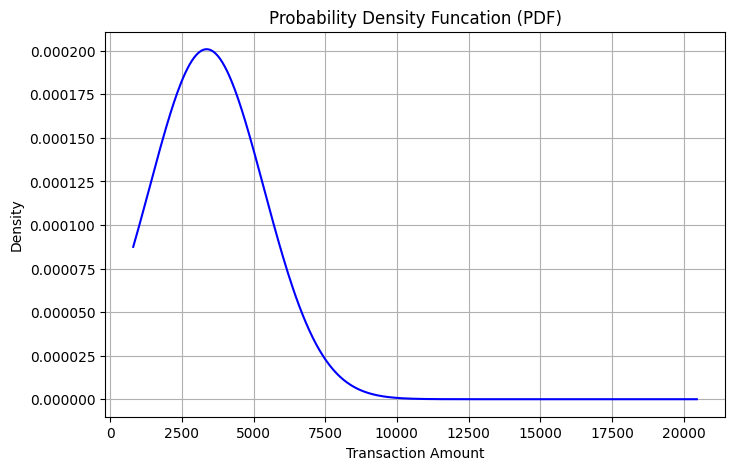

In [68]:
x = np.linspace(amt.min(), amt.max(), 500)
# PDF 

pdf = norm.pdf(x, mean, std)

plt.figure(figsize=(8,5))
plt.plot(x, pdf, color = "blue")
plt.title("Probability Density Funcation (PDF)")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.grid(True)
plt.show()

## Interpretation (PDF)

The PDF (Probability Density Function) shows how transaction amounts are distributed.

The highest point of the curve represents the range where transaction amounts are most likely to occur.

The probability decreases as the transaction amount moves away from the average value.

## CDF

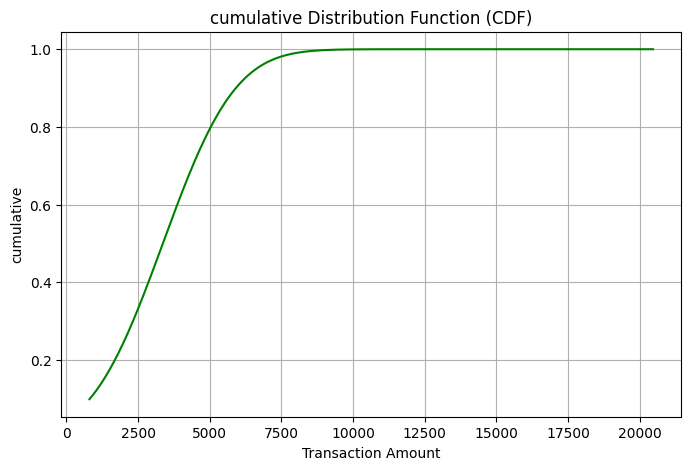

In [69]:
cdf = norm.cdf(x,mean,std)

plt.figure(figsize=(8,5))
plt.plot(x, cdf, color = "green")
plt.title("cumulative Distribution Function (CDF)")
plt.xlabel("Transaction Amount")
plt.ylabel("cumulative")
plt.grid(True)
plt.show()


## Interpretation (CDF)

The CDF (Cumulative Distribution Function) shows the cumulative probability of transaction amounts.

The curve starts near 0 and gradually increases to 1.

It represents the probability that a transaction amount is less than or equal to a given value.

## Question 8: Conclude Which Distribution Best Fits the Dataset and Justify Insights for Decision-Making

## Conclusion

Based on the analysis of the transaction dataset:

• Bernoulli Distribution successfully modeled the transaction occurrence because each transaction has only two possible outcomes: Success (1) or Failure (0).

• Binomial Distribution was appropriate for analyzing the weekly transaction counts, showing that most weeks had a consistent number of transactions.

• Poisson Distribution effectively modeled the number of transactions per day, with the highest probability around the average daily transaction count.

• Log-Normal Distribution provided the best fit for the transaction amount data because the amounts are positive and right-skewed.

• Power Law Distribution did not fit the transaction amounts well, as the fitted curve showed a poor match with the observed data.

• The Q-Q Plot indicated that the transaction amounts are not normally distributed due to right skewness and the presence of high-value outliers.

• The Box-Cox Transformation reduced skewness and stabilized the variance, making the data closer to a normal distribution.

• The Z-Score analysis and PDF/CDF helped identify the probability of high-value transactions and understand the distribution of transaction amounts.

## Final Conclusion

Among all the distributions tested, the Log-Normal Distribution is the best fit for the transaction amount data because it closely follows the observed histogram and accurately represents the positive, right-skewed nature of the data. Therefore, the Log-Normal Distribution is the most suitable model for analyzing transaction amounts in this dataset.

## Decision-Making Insights 

•Most transactions are low to medium value, while high-value transactions are rare.

•Daily transaction counts follow a predictable pattern, making Poisson Distribution useful for forecasting transaction volume.

•The Log-Normal Distribution can help estimate transaction amount probabilities and support financial planning.

•Box-Cox Transformation improves the data quality for statistical analysis and machine learning models.

• Identifying high-value transactions using Z-Scores can assist in fraud detection, risk assessment, and customer behavior analysis.